# Decision Tree Classifiers and Ensemble Methods


**Recitation**

This notebook aims to introduce decision tree classifiers and different types of ensembling methods and how they can be used in binary classification tasks.

Please:

* Work in small groups (course assistants will join to help guide discussion!)
* Discuss your reasoning with each other.
* Write short answers in the markdown cells provided.

## Decision Trees

[Decision Trees (DTs)](https://www.taylorfrancis.com/books/mono/10.1201/9781315139470/classification-regression-trees-leo-breiman) are a non-parametric supervised learning approach which can be used for classification or regression. The aim of a DT is to create a model that would help predict a target variable using simple decision rules, typically inferred from a set of examples.

**Discussion**
1. Why might we want to use a DT?
2. What is a non-parametric vs. parametric model?
3. What are some advantages of decision trees compared to linear models?
4. When might a standard DT perform poorly? Why?

*Your answer here.*

Now we will implement a DT using sklearn.

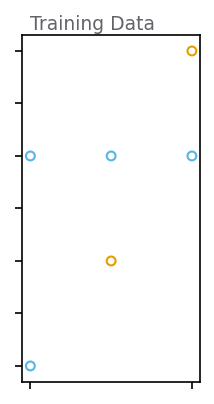

In [1]:
# Lets first create a basic dataset for binary classification
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt
BLUE, ORANGE, GRAY = '#57B5E8', '#E69E00', '#646369'

# Our training data X is composed of two features, and our predictions are 0 or 1
X = np.array([[0, 0], [1, 1], [2,2], [2,3], [0,2], [1,2]])
Y = np.array([0, 1, 0, 1, 0, 0 ])

def plot_data(X, Y):
    fig, ax = plt.subplots(figsize=(3, 3), dpi=150)
    ax.set_aspect(1.3)
    ax.scatter(X[:, 0], X[:, 1], s=18, facecolors='none',
               edgecolors=np.array([BLUE, ORANGE])[Y])
    ax.tick_params(
        bottom=True, left=True, labelleft=False, labelbottom=False)
    ax.text(0, 3.2, 'Training Data', color=GRAY, fontsize=9)
    return fig, ax

_, _ = plot_data(X, Y)


**Discussion**

Before we build a DT:


1.   Will a DT be able to perfectly separate this data? Why or why not?
2.   How many splits will it need to obtain the highest possible accuracy on the above data?


*Your answer here.*

Now, let's define and build a Decision Tree classifier on this data set.

In [2]:
# Default splitting is done using Gini impurity, we will use entropy for our exercise.
clf = tree.DecisionTreeClassifier(criterion="entropy")
clf.fit(X,Y)

DecisionTreeClassifier(criterion='entropy')

**Discussion**


1.   What are these measures, Gini impurity and entropy, used for?
2.   Please explain the difference between them.
3.   What are some other measures that we could use?




*Your answer here.*

Let's now create a test set with 2-dimensional features representing a set of random real-valued numbers to evaluate the classification performance of our Decision Tree classifier.

In [3]:
test_X = 3 + 2.5 * np.random.randn(10, 2)
print(test_X)
clf.predict(test_X)

[[ 3.75006508  3.42803578]
 [ 6.68112595 -2.01420088]
 [ 1.98335406  3.56127683]
 [ 4.43160227  6.08230343]
 [ 2.86012663  2.33129428]
 [ 6.55928981  1.23170466]
 [ 6.18555562 -0.57608731]
 [ 8.91847248 -1.95771275]
 [ 1.27163057  1.83649443]
 [-2.37530236  9.16722206]]


array([1, 1, 1, 1, 0, 1, 1, 1, 0, 1])

In [4]:
# We can also see the probability with which the classifier assigns each class for every sample
clf.predict_proba(test_X)

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.]])

We can also inspect the parameters of the tree.

In [5]:
clf.get_n_leaves()

np.int64(4)

Please check the documentation of the [DT in Sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) and inspect the parameters that define and restrict the usage of DTs.

The decision tree seems to be pretty confident on all of its predictions. Any ideas how we can confuse it?

**HINT:** Here probability can be thought of as the number of samples in the leaf node with the same class

0


<Figure size 640x480 with 0 Axes>

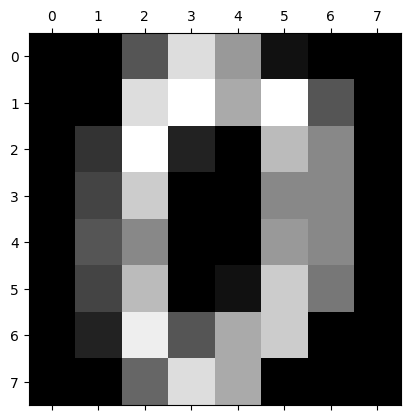

In [6]:
# This was just a synthetic dataset, lets try the decision tree on a more meaningful one
from sklearn.datasets import load_digits
import graphviz

# We use the digits dataset provided by sklearn, this is similar to MNIST but much coarser (8x8) and
# thus a lot lighter than MNIST (28x28)
dataset = load_digits()
X, Y = dataset.data, dataset.target
idxs = np.arange(0, len(X))
np.random.shuffle(idxs)
train_idxs,test_idxs = idxs[:1500], idxs[1500:]
train_X, train_Y = X[train_idxs], Y[train_idxs]
test_X, test_Y = X[test_idxs], Y[test_idxs]
plt.gray()
plt.matshow(dataset.images[0])
print(dataset.target[0])

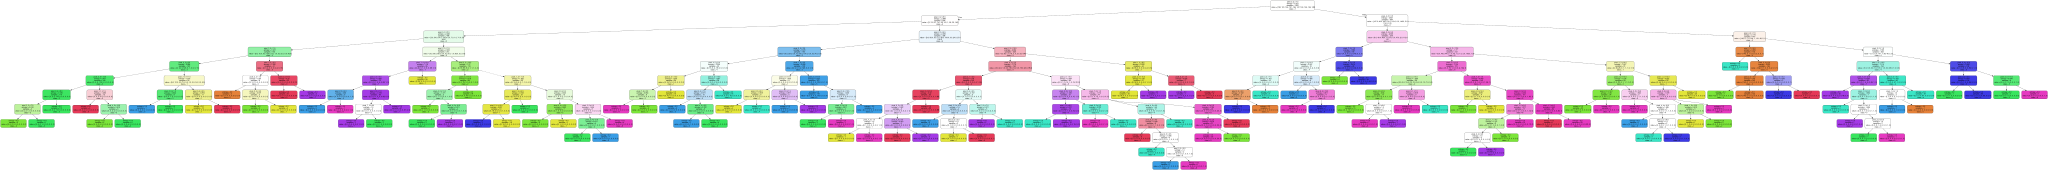

In [7]:
clf = tree.DecisionTreeClassifier(criterion='entropy')
clf = clf.fit(train_X, train_Y)

class_names = [str(c) for c in np.unique(train_Y)]
feature_names = getattr(dataset,
                        "feature_names",
                         [f"f{i}" for i in range(train_X.shape[1])])

dot_data = tree.export_graphviz(clf, out_file=None,
                      feature_names=feature_names,
                      class_names=class_names,
                      filled=True, rounded=True,
                      special_characters=True)
graph = graphviz.Source(dot_data)
graph.render("graph", format="png", cleanup=True)
from IPython.display import display
display(graph)

In [8]:
# Predict using the fitted decision tree and calculate accuracy
preds = clf.predict(test_X)
print(f"Test accuracy is: {np.sum(preds == test_Y)/len(preds)}")

Test accuracy is: 0.835016835016835


In [9]:
train_preds = clf.predict(train_X)
print(f"Train accuracy is: {np.sum(train_preds == train_Y)/len(train_preds)}")

Train accuracy is: 1.0


**Discussion**

1.   What phenomenon do you observe with the DT performance?
2.   What are some ways we could mitigate this issue? Below, try one of them out to see if you can fix the problem!

*Your answer here.*

In [ ]:
## Your code to fix the problem here.

**Discussion**


1.   When trying to fix the issue, is there anything you noticed about the variance of the results when retraining the tree?
2. How might we mitigate the variance issue?


*Your answer here.*

## Bagging

One way is by using bagging! A [Bagging Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html) uses an ensemble of smaller classifiers, each of which are fit on random subsets of the original dataset. Their individual predictions are then aggregated (either by voting or by averaging) to form a final prediction.



In [10]:
from sklearn.ensemble import BaggingClassifier

# Remember, Bagging is just using an ensemble of decision trees to add more variance to your model.
# So we simply wrap our original DecisionTreeClassifier with a BaggingClassifier module.
clf = BaggingClassifier(
    estimator=tree.DecisionTreeClassifier(criterion='entropy'),
    n_estimators=50, max_samples=1.0, max_features=1.0, bootstrap=True)
clf = clf.fit(train_X, train_Y)

In [11]:
preds = clf.predict(test_X)

In [12]:
print(np.sum(preds == test_Y)/len(preds))

0.9326599326599326


**Discussion**
1. Why does training multiple models on random subsets help?
2. Why do we want to sample with replacement?
3. What is the effect of n_estimators? Of estimator?
4. How is a Random Forest different from bagging?

*Your answer here.*

## Exercise 1: Random Forests

Let's now implement the [Random Forests](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) algorithm which is another ensembling method for decision trees. In Random Forests ensembling, each sampled feature in the subset is evaluated in the classification task, and only the best split feature from the subset is used to split each node in the tree.

Print the train/test performance and comment on the performance compared with vanilla bagging.

DT train acc: 1.0
DT test  acc: 0.5


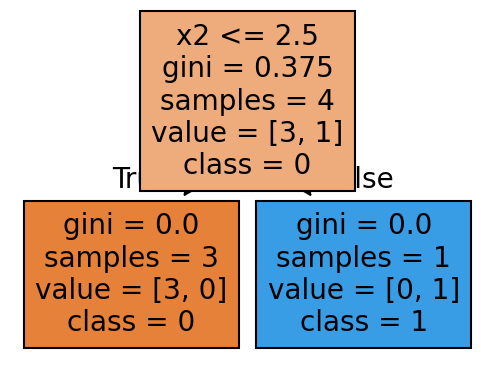

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Toy data (your screenshot)
X = np.array([[0,0],[1,1],[2,2],[2,3],[0,2],[1,2]])
y = np.array([0,1,0,1,0,0])

# train/test split
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# model
dt = DecisionTreeClassifier(max_depth=2, random_state=0)
dt.fit(Xtr, ytr)

print("DT train acc:", accuracy_score(ytr, dt.predict(Xtr)))
print("DT test  acc:", accuracy_score(yte, dt.predict(Xte)))

# (optional) visualize tree
plt.figure(figsize=(4,3), dpi=150)
plot_tree(dt, filled=True, feature_names=["x1","x2"], class_names=["0","1"])
plt.show()


In [17]:
ada = AdaBoostClassifier(
    estimator=base,
    n_estimators=200,
    learning_rate=0.5,
    algorithm="SAMME",     # ← use SAMME in your version
    random_state=1
)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost train acc: 0.7857142857142857
AdaBoost test  acc: 0.7466666666666667


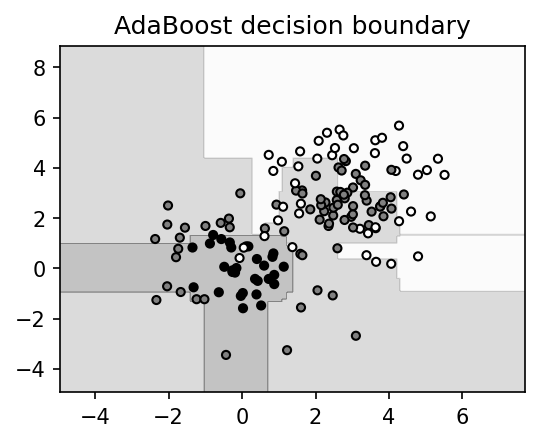

In [19]:
# Implement random forests using sklearn
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_gaussian_quantiles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# dataset like your cell
X1, y1 = make_gaussian_quantiles(cov=2.0,  n_samples=200, n_features=2, n_classes=2, random_state=1)
X2, y2 = make_gaussian_quantiles(mean=(3,3), cov=1.5, n_samples=300, n_features=2, n_classes=2, random_state=1)
X = np.vstack([X1, X2])
y = np.hstack([y1, y2+1]) - 1   # ensure labels are {0,1}

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

# weak learner = decision stump (max_depth=1)
base = DecisionTreeClassifier(max_depth=1, random_state=1)
ada = AdaBoostClassifier(
    estimator=base,
    n_estimators=200,
    learning_rate=0.5,
    algorithm="SAMME",     # ← use SAMME in your version
    random_state=1
)

ada.fit(Xtr, ytr)
print("AdaBoost train acc:", accuracy_score(ytr, ada.predict(Xtr)))
print("AdaBoost test  acc:", accuracy_score(yte, ada.predict(Xte)))

# decision boundary
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300),
)
Z = ada.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(4,3), dpi=150)
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(Xte[:,0], Xte[:,1], c=yte, s=15, edgecolors='k')
plt.title("AdaBoost decision boundary")
plt.show()


## Exercise 2: Adaptive boosting

Next we implement adaptive boosting, in particular the [Adaboost](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostClassifier.html) algorithm.

An important note here is that adaptive boosting algorithms involve iteratively improving the decision trees and hence involve a learning rate similar to logistic regressions, which may need tuning in order to get the best performance.

First, comment on how Adaboost differs from bagging conceptually.
Second, comment on when and why you would want to use Adaboost. Would you use Adaboost in any of these two examples?

> Example 1: You have a small, clean dataset where a simple decision stump performs poorly because the relationship between features and labels is nonlinear.

> Example 2: You have a large dataset with lots of noisy or mislabeled examples (e.g., social media sentiment data with inconsistent labels).

Third, implement Adaboost using sklearn. Print the accuracy. Comment on any performance differences compared with the algorithms we have looked at so far.

*Your answer here.*

In [20]:
# Next we the Adaboost algorithm!
import matplotlib.pyplot as plt

from sklearn.ensemble import AdaBoostClassifier
from sklearn.datasets import make_gaussian_quantiles

# Construct dataset
X1, y1 = make_gaussian_quantiles(
    cov=2.0, n_samples=200, n_features=2, n_classes=2, random_state=1
)
X2, y2 = make_gaussian_quantiles(
    mean=(3, 3), cov=1.5, n_samples=300, n_features=2, n_classes=2, random_state=1
)
X = np.concatenate((X1, X2))
y = np.concatenate((y1, -y2 + 1))


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost train acc: 0.7857142857142857
AdaBoost test  acc: 0.7466666666666667


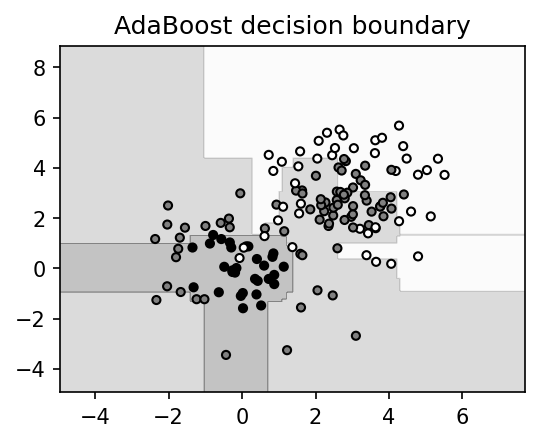

In [21]:
import matplotlib.pyplot as plt
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_gaussian_quantiles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# dataset like your cell
X1, y1 = make_gaussian_quantiles(cov=2.0,  n_samples=200, n_features=2, n_classes=2, random_state=1)
X2, y2 = make_gaussian_quantiles(mean=(3,3), cov=1.5, n_samples=300, n_features=2, n_classes=2, random_state=1)
X = np.vstack([X1, X2])
y = np.hstack([y1, y2+1]) - 1   # ensure labels are {0,1}

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

# weak learner = decision stump (max_depth=1)
base = DecisionTreeClassifier(max_depth=1, random_state=1)
ada = AdaBoostClassifier(
    estimator=base,
    n_estimators=200,
    learning_rate=0.5,
    algorithm="SAMME",     # ← use SAMME in your version
    random_state=1
)

ada.fit(Xtr, ytr)
print("AdaBoost train acc:", accuracy_score(ytr, ada.predict(Xtr)))
print("AdaBoost test  acc:", accuracy_score(yte, ada.predict(Xte)))

# decision boundary
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-1, X[:,0].max()+1, 300),
    np.linspace(X[:,1].min()-1, X[:,1].max()+1, 300),
)
Z = ada.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.figure(figsize=(4,3), dpi=150)
plt.contourf(xx, yy, Z, alpha=0.25)
plt.scatter(Xte[:,0], Xte[:,1], c=yte, s=15, edgecolors='k')
plt.title("AdaBoost decision boundary")
plt.show()
